# GNSS Spoof Detection – Final Pipeline

This notebook implements the final machine learning pipeline for detecting GNSS spoofing attacks.

Pipeline steps:

1. Load dataset
2. Data preprocessing
3. Feature engineering
4. Train-validation split
5. Model training
6. Validation
7. Test prediction
8. Submission generation

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight

## Load Training Dataset

In [2]:
train = pd.read_csv("../data/train.csv", low_memory=False)

train.head()

,time,channel,PRN,Carrier_Doppler_hz,Pseudorange_m,RX_time,TOW,Carrier_phase,EC,LC,PC,PIP,PQP,TCD,CN0,spoofed
0,0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,0
1,0,ch1,ch1,ch1,ch1,ch1,ch1,ch1,ch1,ch1,ch1,ch1,ch1,ch1,ch1,0
2,0,ch2,ch2,ch2,ch2,ch2,ch2,ch2,ch2,ch2,ch2,ch2,ch2,ch2,ch2,0
3,0,ch3,ch3,ch3,ch3,ch3,ch3,ch3,ch3,ch3,ch3,ch3,ch3,ch3,ch3,0
4,0,ch4,ch4,ch4,ch4,ch4,ch4,ch4,ch4,ch4,ch4,ch4,ch4,ch4,ch4,0


## Data Preprocessing

In [3]:
train['channel'] = train['channel'].str.replace('ch','').astype(int)

cols = ['PRN','Carrier_Doppler_hz','Pseudorange_m','RX_time','TOW',
        'Carrier_phase','EC','LC','PC','PIP','PQP','TCD','CN0']

for c in cols:
    train[c] = pd.to_numeric(train[c], errors='coerce')

train = train.dropna()

## Feature Engineering

In [4]:
train['CN0_mean_time'] = train.groupby('time')['CN0'].transform('mean')
train['doppler_mean_time'] = train.groupby('time')['Carrier_Doppler_hz'].transform('mean')
train['pseudo_mean_time'] = train.groupby('time')['Pseudorange_m'].transform('mean')

train['CN0_std_time'] = train.groupby('time')['CN0'].transform('std')
train['doppler_std_time'] = train.groupby('time')['Carrier_Doppler_hz'].transform('std')
train['pseudo_std_time'] = train.groupby('time')['Pseudorange_m'].transform('std')

train['corr_diff'] = train['EC'] - train['LC']

## Drop Unnecessary Columns

In [5]:
train = train.drop(['TOW'], axis=1)

## Prepare Training Data

In [6]:
X = train.drop(['spoofed','time','RX_time'], axis=1)
y = train['spoofed']

## Train Validation Split (Stratified)

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Handle Class Imbalance

In [8]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

## Model Training

In [9]:
model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_depth=8
)

model.fit(X_train, y_train, sample_weight=sample_weights)

,loss,'log_loss'
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,8
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


## Model Validation

In [10]:
val_pred = model.predict(X_val)

print("Weighted F1 Score:", f1_score(y_val, val_pred, average='weighted'))

Weighted F1 Score: 0.9730189182725936


## Load Test Dataset

In [11]:
test = pd.read_csv("../data/test.csv", low_memory=False)

test.head()

,time,channel,PRN,Carrier_Doppler_hz,Pseudorange_m,RX_time,TOW,Carrier_phase,EC,LC,PC,PIP,PQP,TCD,CN0
0,111402,ch0,8,4749.068417,4.841489e+06,263154.82,263154.803851,-435396.111594,101998.429688,100788.812500,111415.289062,-107731.039062,-28414.615234,4660.467773,43.559540
1,111402,ch1,9,1995.777378,2.449848e+06,263154.82,263154.811828,-201479.950180,100812.039062,98424.367188,109174.476562,-105347.234375,-28653.570312,1997.164185,47.116425
2,111402,ch2,27,3458.024120,3.738822e+06,263154.82,263154.807529,-356000.635312,138335.140625,125640.570312,138446.281250,137254.781250,-18124.476562,3467.803955,45.687332
3,111402,ch3,26,-2105.992470,5.482371e+06,263154.82,263154.801713,193102.504674,84470.195312,84153.156250,95917.468750,95899.140625,1874.903442,-2109.972656,42.264256
4,111402,ch4,4,-493.638193,2.666526e+06,263154.82,263154.811105,48203.346004,103226.210938,100365.203125,114574.656250,-114160.539062,-9732.571289,-494.215881,43.629795


## Test Data Preprocessing

In [12]:
test['channel'] = test['channel'].str.replace('ch','').astype(int)

for c in cols:
    test[c] = pd.to_numeric(test[c], errors='coerce')

test = test.dropna()

## Feature Engineering (Test Data)

In [13]:
test['CN0_mean_time'] = test.groupby('time')['CN0'].transform('mean')
test['doppler_mean_time'] = test.groupby('time')['Carrier_Doppler_hz'].transform('mean')
test['pseudo_mean_time'] = test.groupby('time')['Pseudorange_m'].transform('mean')

test['CN0_std_time'] = test.groupby('time')['CN0'].transform('std')
test['doppler_std_time'] = test.groupby('time')['Carrier_Doppler_hz'].transform('std')
test['pseudo_std_time'] = test.groupby('time')['Pseudorange_m'].transform('std')

test['corr_diff'] = test['EC'] - test['LC']

## Test Prediction

In [14]:
X_test = test.drop(['time','TOW','RX_time'], axis=1)

test_prob = model.predict_proba(X_test)[:,1]

test['prob'] = test_prob

## Aggregate Predictions by Time

In [15]:
time_prob = test.groupby('time')['prob'].mean().reset_index()

## Apply Detection Threshold

In [16]:
time_prob['Spoofed'] = (time_prob['prob'] > 0.05).astype(int)

## Generate Submission File

In [17]:
submission = pd.read_csv("../data/submission_format.csv")

submission['Spoofed'] = time_prob['Spoofed']
submission['Confidence'] = time_prob['prob']

submission.to_csv("../submission_final.csv", index=False)

submission.head()

,time,Spoofed,Confidence
0,111402,0,9.592375e-07
1,111403,0,9.564794e-07
2,111404,0,9.940842e-07
3,111405,0,9.757832e-07
4,111406,0,9.328891e-07


## Feature Importance (Permutation Importance)

To understand which GNSS features contribute most to spoof detection,
we compute permutation importance.

Permutation importance measures how much the model performance changes
when the values of a feature are randomly shuffled. If shuffling a feature
causes a large drop in model performance, that feature is considered important.

This helps interpret which GNSS measurements influence the model.

In [18]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_train,
    y_train,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)

importance

,feature,importance
13,doppler_mean_time,1.598800e-01
14,pseudo_mean_time,7.307894e-02
16,doppler_std_time,6.230311e-02
17,pseudo_std_time,5.529829e-02
12,CN0_mean_time,1.653908e-02
15,CN0_std_time,1.572305e-03
4,Carrier_phase,2.945442e-05
3,Pseudorange_m,7.012957e-06
7,PC,0.000000e+00
0,channel,-2.805183e-07


## Feature Importance Visualization

The plot below shows the relative importance of each feature based on
permutation importance.

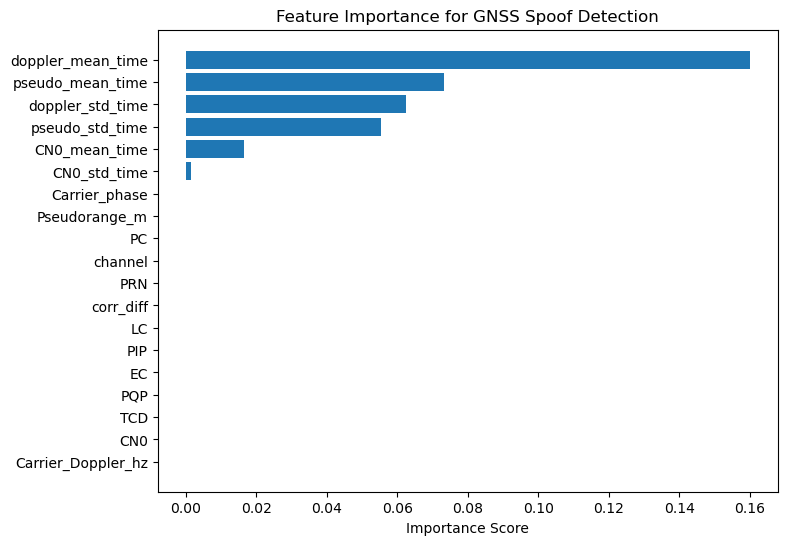

In [19]:
import matplotlib.pyplot as plt

importance_sorted = importance.sort_values("importance", ascending=True)

plt.figure(figsize=(8,6))
plt.barh(importance_sorted["feature"], importance_sorted["importance"])
plt.xlabel("Importance Score")
plt.title("Feature Importance for GNSS Spoof Detection")
plt.show()